In [1]:
import jax
import jax.numpy as jnp
import netket as nk
import netket.experimental as nkx
import numpy as np
from pyscf import gto, scf, fci
from flax import linen as nn
import flax.nnx as nnx
import optax
from tqdm import tqdm
import time 
from functools import partial
from jax import flatten_util
from VMC_tool import hi, edges,ha,SingleStateAnsatz,create_machine,compute_local_energies,\
    compute_qgt,forces_expect_hermitian,E_fcis

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


H₂ FCI 基准能量
E0 = -0.93725495 Ha  |  激发能: 0.0000 eV
E1 = -0.93098087 Ha  |  激发能: 0.1707 eV
E2 = -0.37473199 Ha  |  激发能: 15.3070 eV
E3 = -0.36644094 Ha  |  激发能: 15.5326 eV


In [2]:

bond_length = 2.4
geometry = [('H', (0., 0., 0.)), ('H', (bond_length, 0., 0.))]
mol = gto.M(atom=geometry, basis='STO-3G', verbose=0)
mf = scf.RHF(mol).run(verbose=0)

cisolver = fci.FCI(mf)
cisolver.nroots = 4
E_fcis, fcivec = cisolver.kernel()
print("="*60)
print("H₂ FCI 基准能量")
print("="*60)
for i, e in enumerate(E_fcis):
    exc = (e - E_fcis[0]) * 27.2114
    print(f"E{i} = {e:.8f} Ha  |  激发能: {exc:.4f} eV")

# ha = nkx.operator.from_pyscf_molecule(mol)
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=2,
    s=1/2,
    n_fermions_per_spin=(1,1),
)
E_hf = mf.e_tot
print(f"HF 基态能量: {E_hf:.8f} Ha")

H₂ FCI 基准能量
E0 = -0.93725495 Ha  |  激发能: 0.0000 eV
E1 = -0.93098087 Ha  |  激发能: 0.1707 eV
E2 = -0.37473199 Ha  |  激发能: 15.3070 eV
E3 = -0.36644094 Ha  |  激发能: 15.5326 eV
HF 基态能量: -0.71591006 Ha


In [3]:
import jax
import jax.numpy as jnp
from functools import partial

# ==============================================
# 1. 生成随机初始态
# ==============================================
def generate_random_initial_states(hi, n_chains: int, seed: int = 42):
    key = jax.random.PRNGKey(seed)
    keys = jax.random.split(key, n_chains)
    return jax.vmap(lambda k: hi.random_state(k))(keys)

# ==============================================
# 2. 候选状态生成
# ==============================================
def make_get_all_next_states(edges):
    @jax.jit
    def get_all_next_states_jit(S: jnp.ndarray):
        next_states = []
        valid_masks = []
        for (i, j) in edges:
            occ_i = S[..., i]
            occ_j = S[..., j]
            valid = (occ_i != occ_j)
            new_state = S.at[..., i].set(occ_j).at[..., j].set(occ_i)
            next_states.append(new_state)
            valid_masks.append(valid)
        return jnp.stack(next_states), jnp.stack(valid_masks)
    return get_all_next_states_jit

# ==============================================
# 3. Metropolis 单步跃迁
# ==============================================
def make_metropolis_hastings_step(edges, machine):
    get_all_next = make_get_all_next_states(edges)
    
    @jax.jit
    def mh_step(params, state: jnp.ndarray, key: jax.Array):
        candidates, valid_mask = get_all_next(state[None, :])
        candidates = candidates[:, 0]
        valid_mask = valid_mask[:, 0]
        
        key, subk = jax.random.split(key)
        idx = jax.random.choice(subk, len(edges))
        cand = candidates[idx]
        is_valid = valid_mask[idx]
        
        log_curr = machine(params, state)
        log_cand = machine(params, cand)
        log_acc = 2 * jnp.real(log_cand - log_curr)
        
        key, subk = jax.random.split(key)
        accept = is_valid & (log_acc > jnp.log(jax.random.uniform(subk)))
        new_state = jnp.where(accept, cand, state)
        return new_state, key
    
    return mh_step

# ==============================================
# 🔥 最终版：带 sampler_state + 随机数管理 + 对齐 NetKet
# ==============================================
@partial(jax.jit, static_argnums=(0,1,3,4,6))
def mcmc_sampler_multichain(
    n_samples_per_chain: int,
    n_warmup: int,             # 单位：sweep
    sampler_state: tuple,      # ✅ NetKet 风格状态：(current_states, chain_keys)
    edges: tuple,
    machine: callable,
    params: dict,
    sweep_size: int = 32       # ✅ 保留 sweep_size
):
    # 解开 sampler_state（和 NetKet 完全一致）
    current_states, current_keys = sampler_state
    n_chains = current_states.shape[0]
    mh_step = make_metropolis_hastings_step(edges, machine)

    # -------------------------
    # 一次 sweep = 连续跳 sweep_size 次
    # -------------------------
    def single_sweep(carry, _):
        states, keys = carry
        # 多链并行 VMAP
        (new_s, new_k), _ = jax.lax.scan(
            lambda c, _: (jax.vmap(mh_step, in_axes=(None, 0, 0))(params, c[0], c[1]), None),
            (states, keys),
            length=sweep_size
        )
        return (new_s, new_k), new_s

    # -------------------------
    # 1) Warmup（仅更新状态，不保存样本）
    # -------------------------
    if n_warmup > 0:
        (current_states, current_keys), _ = jax.lax.scan(
            single_sweep, (current_states, current_keys), length=n_warmup
        )

    # -------------------------
    # 2) 正式采样（保存样本 + 更新最终状态）
    # -------------------------
    (final_states, final_keys), samples = jax.lax.scan(
        single_sweep, (current_states, current_keys), length=n_samples_per_chain
    )

    # 打包新的 sampler_state（返回给下一次迭代）
    new_sampler_state = (final_states, final_keys)
    
    # 展平样本：[n_samples, n_chains, n_sites] → [n_samples*n_chains, n_sites]
    samples_flat = samples.reshape(-1, current_states.shape[-1])
    return samples_flat, new_sampler_state

In [4]:
# 初始化链状态 + 随机数状态（构成 sampler_state）
def init_sampler_state(hi, n_chains, seed=42):
    init_states = generate_random_initial_states(hi, n_chains, seed)
    key = jax.random.PRNGKey(seed)
    chain_keys = jax.random.split(key, n_chains)  # 每条链独立随机数
    return (init_states, chain_keys)

In [5]:
class SingleStateAnsatz(nnx.Module):
    def __init__(self, n_spin_orbitals: int, hidden_dim=16, *, rngs: nnx.Rngs):
        super().__init__()
        self.linear1 = nnx.Linear(n_spin_orbitals, hidden_dim, rngs=rngs, param_dtype=jnp.float32)
        self.linear2 = nnx.Linear(hidden_dim, hidden_dim, rngs=rngs, param_dtype=jnp.float32)
        self.output = nnx.Linear(hidden_dim, 1, rngs=rngs, param_dtype=jnp.float32)

    def __call__(self, x):
        h = nnx.tanh(self.linear1(x.astype(jnp.float32)))
        h = nnx.tanh(self.linear2(h))
        out = self.output(h)
        return jnp.squeeze(out)

In [6]:
# ======================
# 超参数
# ======================
N_CHAINS = 16
N_WARMUP = 32
N_SAMPLES_PER_CHAIN = 100
SWEEP_SIZE = 32

# ======================
# 初始化 ONCE
# ======================
rngs = nnx.Rngs(21)
model = SingleStateAnsatz(4, hidden_dim=8, rngs=rngs)
machine, graphdef, params = create_machine(model)

sampler_state = init_sampler_state(hi, N_CHAINS, seed=42)
samples, sampler_state = mcmc_sampler_multichain(
    n_samples_per_chain=N_SAMPLES_PER_CHAIN,
    n_warmup=N_WARMUP,
    sampler_state=sampler_state,  # ✅ 状态传递
    edges=((0,1),(2,3)),
    machine=machine,
    params=params,
    sweep_size=SWEEP_SIZE
)
samples.shape

(1600, 4)

In [7]:
def statistics(x):
    """计算样本统计量"""
    mean = jnp.mean(x)
    var = jnp.var(x)
    return mean, jnp.sqrt(var / x.shape[0])


@partial(jax.jit, static_argnames=("machine",))
def forces_expect_hermitian(machine, params, sigma):
    """
    核心：复刻 NetKet 的 forces_expect_hermitian 函数
    
    使用 force-based 梯度计算：
    ∇⟨E⟩ = ⟨(E_loc - ⟨E⟩) ∇log ψ⟩
    
    关键：对于复数值网络，使用 holomorphic=True
    """
    # 1. 计算局部能量
    O_loc = compute_local_energies(machine, params, sigma)
    
    # 2. 统计能量均值
    O_mean, O_std = statistics(O_loc)
    
    # 3. 中心化局部能量
    O_centered = O_loc - O_mean
    
    # 4. 计算 ∇log ψ 对每个样本
    # 使用 jax.grad 计算复数梯度（holomorphic=True）
    def log_psi_single(p, s):
        return machine(p, s)
    
    def compute_grad_for_sample(s):
        return jax.grad(lambda p: log_psi_single(p, s), holomorphic=False)(params)
    
    grad_matrix = jax.vmap(compute_grad_for_sample)(sigma)
    
    # 5. 计算 force-based 梯度
    # grad = ⟨(E_loc - E_mean) ∇log ψ⟩ = (1/N) Σ (E_loc[i] - E_mean) ∇log ψ(σ[i])
    # grad_matrix 已经是 PyTree 结构，每个元素的形状是 (n_samples, ...)
    # 关键修复：O_centered 形状为 (n_samples,)，需要正确广播到梯度张量的每个维度
    # 使用 reshape 将 O_centered 变为 (n_samples, 1, 1, ..., 1) 以匹配梯度张量
    def weight_and_mean(grad_component):
        # grad_component 形状：(n_samples, d1, d2, ...)
        # O_centered 形状：(n_samples,)
        # 需要广播相乘后沿 axis=0 求平均
        weights = O_centered.reshape((O_centered.shape[0],) + (1,) * (grad_component.ndim - 1))
        return jnp.mean(weights * jnp.conj(grad_component), axis=0)
    
    grad = jax.tree_util.tree_map(weight_and_mean, grad_matrix)
    
    return O_mean, O_std, grad

#@partial(jax.jit, static_argnames=("machine",))
def compute_qgt(machine, params, sigma, diag_shift=0.1):
    """
    计算量子几何张量（QGT）/ F 矩阵
    
    QGT 定义：
    S_ij = ⟨∂_i log ψ* ∂_j log ψ⟩ - ⟨∂_i log ψ*⟩⟨∂_j log ψ⟩
    
    这就是 NetKet SR 的核心
    
    参数：
    - machine: 波函数机器
    - params: 网络参数
    - sigma: 样本 (n_samples, n_orbitals)
    - diag_shift: 对角线正则化参数 λ
    
    返回：
    - qgt_reg: 正则化后的 QGT 矩阵 (n_params, n_params)
    - unravel_fn: 用于将展平的向量恢复为 PyTree 结构的函数
    """
    n_samples = sigma.shape[0]
    
    # 步骤 1: 计算每个样本的 ∇log ψ
    def log_psi_single(p, s):
        return machine(p, s)
    
    def compute_grad_for_sample(s):
        return jax.grad(lambda p: log_psi_single(p, s), holomorphic=False)(params)
    
    # grad_matrix 是 PyTree，每个元素形状为 (n_samples, ...)
    grad_matrix = jax.vmap(compute_grad_for_sample)(sigma)
    
    # 步骤 2: 将 PyTree 展平为矩阵 (n_samples, n_params)
    grad_flat, unravel_fn = flatten_util.ravel_pytree(grad_matrix)
    grad_flat = grad_flat.reshape(n_samples, -1)
    
    # 步骤 3: 中心化（减去均值）
    # 这对应 QGT 定义中的第二项：- ⟨∂_i log ψ*⟩⟨∂_j log ψ⟩
    grad_mean = jnp.mean(grad_flat, axis=0, keepdims=True)  # (1, n_params)
    grad_centered = grad_flat - grad_mean  # (n_samples, n_params)
    
    # 步骤 4: 计算 QGT = (1/N) * Σ ∇log ψ* ∇log ψ^T
    # 注意：对于复数，需要使用共轭
    qgt = (1.0 / n_samples) * jnp.conj(grad_centered).T @ grad_centered
    
    # 步骤 5: 添加正则化
    qgt_reg = qgt + diag_shift * jnp.eye(qgt.shape[0])
    
    return qgt_reg, unravel_fn

In [8]:
O_mean, O_std, grad = forces_expect_hermitian(machine,params,hi.all_states())


In [9]:
import jax
import jax.numpy as jnp
import optax
import time
from functools import partial
import flax.nnx as nnx

# ===================== 6. 初始化（适配多链） =====================
rngs = nnx.Rngs(21)
model = SingleStateAnsatz(4, hidden_dim=12, rngs=rngs)
machine, graphdef, params = create_machine(model)

optimizer = optax.sgd(learning_rate=0.01)
opt_state = optimizer.init(params)

# 推荐参数（和 NetKet 一样快、一样准）
N_CHAINS = 100
N_SAMPLES_PER_CHAIN = 20
N_WARMUP = 10
SWEEP_SIZE = 32
N_ITER = 300

# ===================== ✅ 关键：初始化 sampler_state（只初始化一次！）=====================
def init_sampler_state(hi, n_chains, seed=42):
    init_states = generate_random_initial_states(hi, n_chains, seed)
    key = jax.random.PRNGKey(seed)
    chain_keys = jax.random.split(key, n_chains)
    return (init_states, chain_keys)

# 初始化一次，后面永远复用、更新
sampler_state = init_sampler_state(hi, N_CHAINS, seed=21)

# ===================== 7. 训练循环（✅ 完全修复版）=====================
print("\n" + "="*60)
print("开始多链 VMC 训练 (自然梯度下降法)")
print("="*60)

history = {
    'step': [],
    'energy': [],
    'energy_std': [],
    'error': []
}
start_time = time.time()

for step in range(N_ITER):
    # ======================================================================
    # ✅ 1. 采样：复用 sampler_state，不每次重新生成初始态！（核心修复）
    # ======================================================================
    samples, sampler_state = mcmc_sampler_multichain(
        n_samples_per_chain=N_SAMPLES_PER_CHAIN,
        n_warmup=N_WARMUP,
        sampler_state=sampler_state,  # 状态传递
        edges=((0,1),(2,3)),
        machine=machine,
        params=params,
        sweep_size=SWEEP_SIZE
    )

    # ======================================================================
    # 2. 能量 & 自然梯度（不变）
    # ======================================================================
    energy, energy_std, grad = forces_expect_hermitian(machine, params, samples)
    grad = jax.tree_map(lambda x: x * 2, grad)

    qgt_reg, qgt_unravel_fun = compute_qgt(machine, params, samples, diag_shift=0.001)
    grad_flat, grad_unravel_fn = flatten_util.ravel_pytree(grad)
    natural_grad_flat = jnp.linalg.solve(qgt_reg, grad_flat)
    natural_grad = grad_unravel_fn(natural_grad_flat)

    # ======================================================================
    # 3. 参数更新
    # ======================================================================
    updates, opt_state = optimizer.update(natural_grad, opt_state, params)
    params = optax.apply_updates(params, updates)

    # ======================================================================
    # 4. 日志
    # ======================================================================
    if step % 50 == 0 or step == N_ITER - 1:
        
                # 1. 监控 log_Psi
        log_Psi_batch = machine(params, samples)
        print(f"log_Psi: mean={log_Psi_batch.mean():.3f} | min={log_Psi_batch.min():.3f} | max={log_Psi_batch.max():.3f}")

        # 2. 监控梯度范数
        grad_norm = jnp.linalg.norm(grad_flat)
        print(f"grad norm = {grad_norm:.4f}")


        # 4. 监控 QGT 条件数（判断是否奇异）
        cond = jnp.linalg.cond(qgt_reg)
        print(f"QGT cond = {cond:.2e}")
        
        
        error = jnp.abs(energy.real - E_fcis[0])
        history['step'].append(step)
        history['energy'].append(float(energy.real))
        history['energy_std'].append(float(energy_std))
        history['error'].append(float(error))
        print(f"Step {step:3d} | E: {energy.real:.8f} ± {energy_std:.6f} | FCI: {E_fcis[0]:.8f} | Error: {error:.6f}")

end_time = time.time()
print(f"\n训练耗时：{end_time - start_time:.2f} 秒")

# ======================================================================
# 最终能量评估
# ======================================================================
final_samples, _ = mcmc_sampler_multichain(
    n_samples_per_chain=N_SAMPLES_PER_CHAIN * 2,
    n_warmup=25,
    sampler_state=sampler_state,
    edges=((0,1),(2,3)),
    machine=machine,
    params=params,
    sweep_size=SWEEP_SIZE
)
final_energy, final_std, _ = forces_expect_hermitian(machine, params, final_samples)
final_error = jnp.abs(final_energy.real - E_fcis[0])

print("\n" + "="*60)
print(f"训练完成!")
print(f"最终能量：{final_energy.real:.8f} ± {final_std:.6f} Ha")
print(f"FCI 基准：{E_fcis[0]:.8f} Ha")
print(f"绝对误差：{final_error:.6f} Ha")
print(f"相对误差：{final_error / jnp.abs(E_fcis[0]) * 100:.4f}%")
print("="*60)


开始多链 VMC 训练 (自然梯度下降法)


/var/folders/8x/k_m4pmb11437ktb_r6tjzt2c0000gn/T/ipykernel_30132/543277631.py:64: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  grad = jax.tree_map(lambda x: x * 2, grad)


log_Psi: mean=0.785 | min=-1.128 | max=1.308
grad norm = 0.3209
QGT cond = 5.67e+02
Step   0 | E: -0.45244771 ± 0.004352 | FCI: -0.93725495 | Error: 0.484807
log_Psi: mean=3.154 | min=3.154 | max=3.154
grad norm = 0.0000
QGT cond = 1.98e+03
Step  50 | E: -0.65249958 ± 0.000000 | FCI: -0.93725495 | Error: 0.284755
log_Psi: mean=3.299 | min=-1.138 | max=3.302
grad norm = 0.0009
QGT cond = 2.05e+03
Step 100 | E: -0.65251845 ± 0.000092 | FCI: -0.93725495 | Error: 0.284737
log_Psi: mean=3.421 | min=-1.248 | max=3.423
grad norm = 0.0009
QGT cond = 2.08e+03
Step 150 | E: -0.65257574 ± 0.000090 | FCI: -0.93725495 | Error: 0.284679
log_Psi: mean=3.494 | min=3.494 | max=3.494
grad norm = 0.0000
QGT cond = 2.12e+03
Step 200 | E: -0.65270112 ± 0.000000 | FCI: -0.93725495 | Error: 0.284554
log_Psi: mean=3.540 | min=3.540 | max=3.540
grad norm = 0.0000
QGT cond = 2.13e+03
Step 250 | E: -0.65271641 ± 0.000000 | FCI: -0.93725495 | Error: 0.284539
log_Psi: mean=3.582 | min=3.582 | max=3.582
grad norm =

Text(0.5, 1.0, 'Energy')

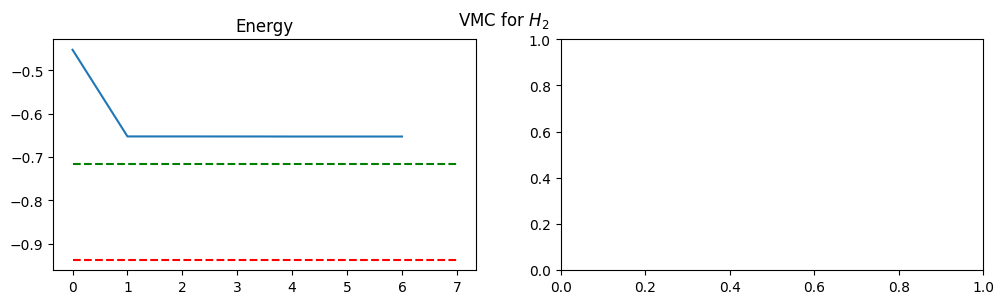

In [11]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12, 3))
fig.suptitle('VMC for $H_2$')
axs[0].plot(history['energy'])
axs[0].hlines(E_fcis[0],0,len(history['energy']),linestyle='--',color='red')
axs[0].hlines(E_hf,0,len(history['energy']),linestyle='--',color='green')
axs[0].set_title('Energy')

